In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

In [2]:
conn = sqlite3.connect("../data/database/superstore.db")

In [3]:
query = """
SELECT p.category,
       ROUND(SUM(od.sales),2) AS total_sales
FROM order_details od
JOIN products p ON od.product_id = p.product_id
GROUP BY p.category
ORDER BY total_sales DESC;
"""

sales_category = pd.read_sql(query, conn)
sales_category

,category,total_sales
0,Technology,4744557.50
1,Furniture,4110874.19
2,Office Supplies,3787070.23


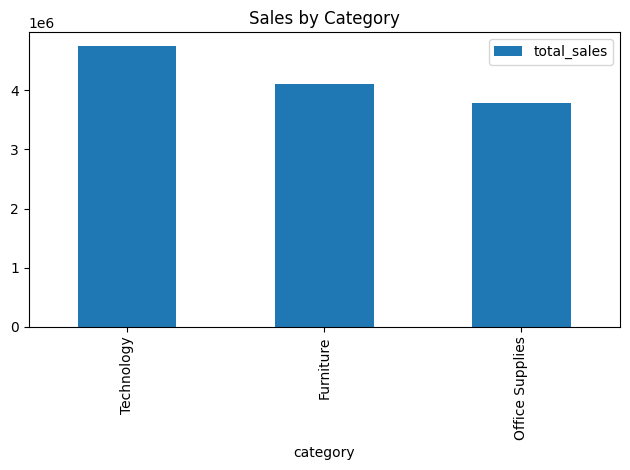

In [6]:
sales_category.plot(
    x="category",
    y="total_sales",
    kind="bar"
)

plt.title("Sales by Category")
plt.tight_layout()

plt.savefig(
    "../reports/Images/sales_by_category.png",
    bbox_inches="tight"
)
plt.show()

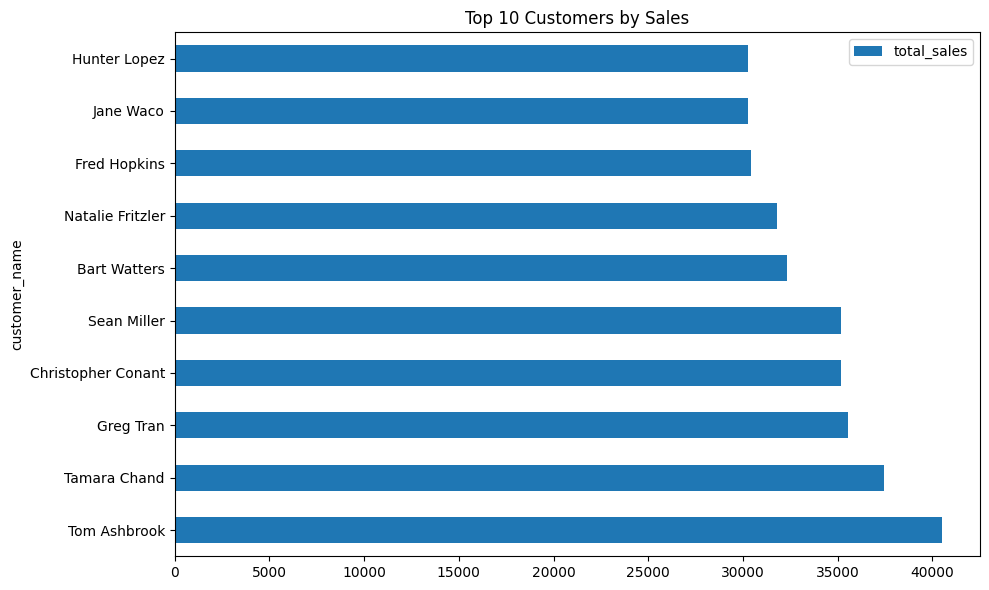

In [8]:
# Top 10 clientes por ventas
query = """
SELECT
    c.customer_name,
    ROUND(SUM(od.sales),2) AS total_sales
FROM order_details od
JOIN customers c
    ON od.customer_id = c.customer_id
GROUP BY c.customer_name
ORDER BY total_sales DESC
LIMIT 10;
"""

top_customers = pd.read_sql(query, conn)
top_customers.plot(
    x="customer_name",
    y="total_sales",
    kind="barh",
    figsize=(10,6)
)

plt.title("Top 10 Customers by Sales")
plt.tight_layout()
plt.savefig("../reports/Images/top_customers.png")
plt.show()

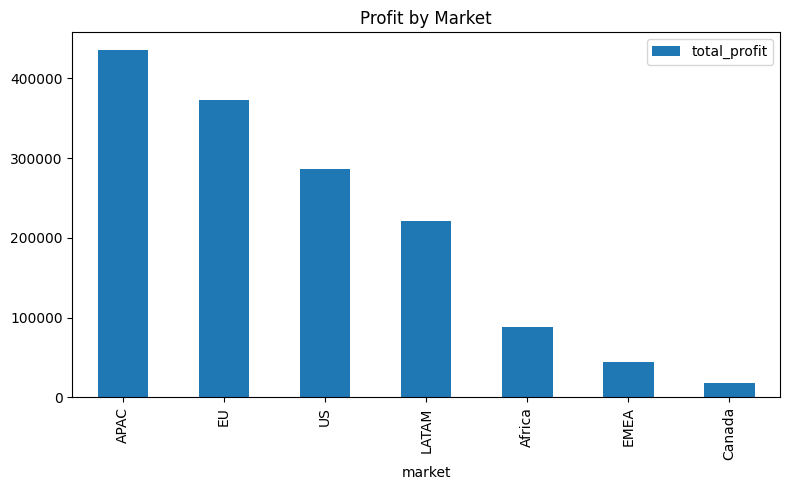

In [9]:
# 3. Profit por mercado
query = """
SELECT
    l.market,
    ROUND(SUM(od.profit),2) AS total_profit
FROM order_details od
JOIN locations l
    ON od.location_id = l.location_id
GROUP BY l.market
ORDER BY total_profit DESC;
"""

profit_market = pd.read_sql(query, conn)
profit_market.plot(
    x="market",
    y="total_profit",
    kind="bar",
    figsize=(8,5)
)

plt.title("Profit by Market")
plt.tight_layout()
plt.savefig("../reports/Images/profit_by_market.png")
plt.show()

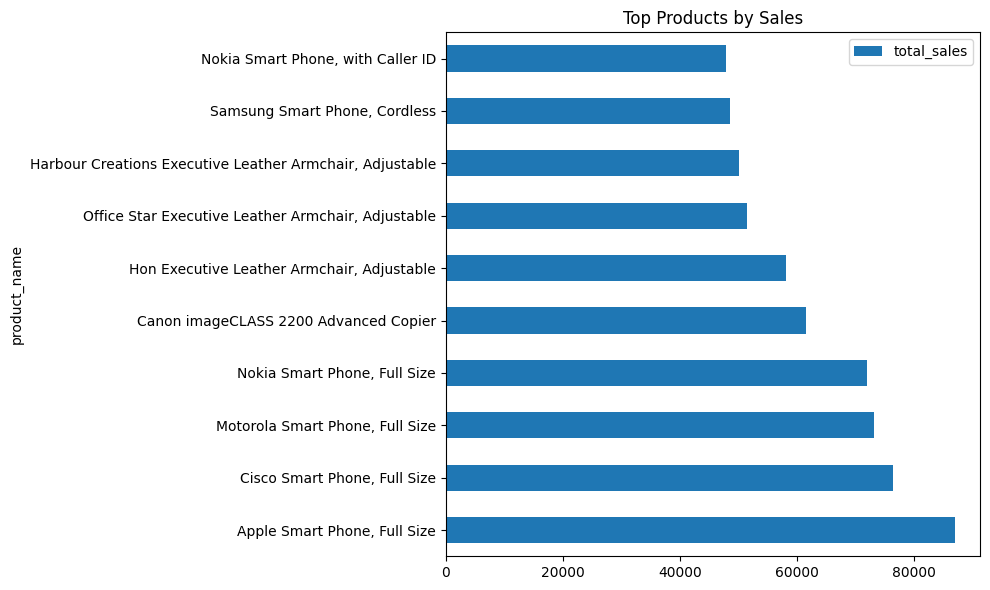

In [10]:
# 4. Top 10 Productos por ventas
query = """
SELECT
    p.product_name,
    ROUND(SUM(od.sales),2) AS total_sales
FROM order_details od
JOIN products p
    ON od.product_id = p.product_id
GROUP BY p.product_name
ORDER BY total_sales DESC
LIMIT 10;
"""

top_products = pd.read_sql(query, conn)
top_products.plot(
    x="product_name",
    y="total_sales",
    kind="barh",
    figsize=(10,6)
)

plt.title("Top Products by Sales")
plt.tight_layout()
plt.savefig("../reports/Images/top_products_sales.png")
plt.show()

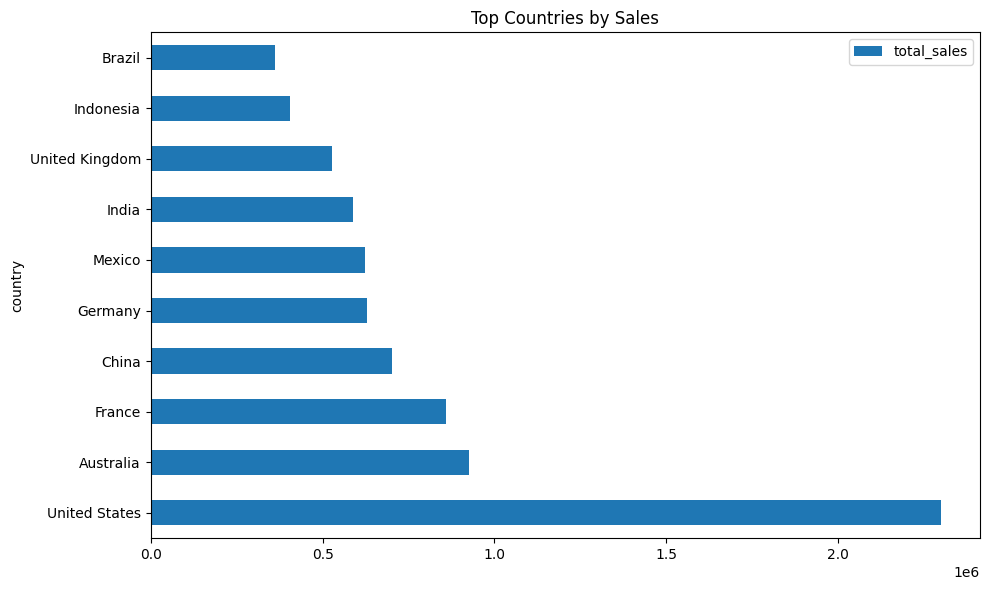

In [11]:
# 5. Ventas por pais
query = """
SELECT
    l.country,
    ROUND(SUM(od.sales),2) AS total_sales
FROM order_details od
JOIN locations l
    ON od.location_id = l.location_id
GROUP BY l.country
ORDER BY total_sales DESC
LIMIT 10;
"""

sales_country = pd.read_sql(query, conn)
sales_country.plot(
    x="country",
    y="total_sales",
    kind="barh",
    figsize=(10,6)
)

plt.title("Top Countries by Sales")
plt.tight_layout()
plt.savefig("../reports/Images/sales_country.png")
plt.show()

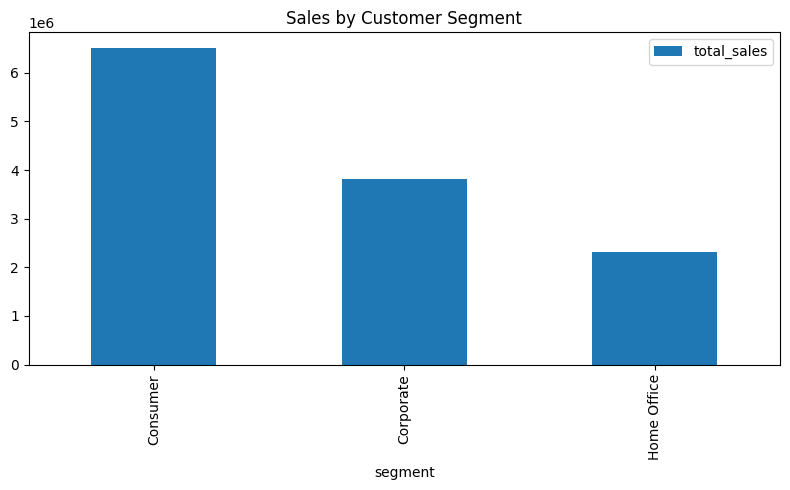

In [12]:
# 6. Ventas por segmento de cliente
query = """
SELECT
    c.segment,
    ROUND(SUM(od.sales),2) AS total_sales
FROM order_details od
JOIN customers c
    ON od.customer_id = c.customer_id
GROUP BY c.segment
ORDER BY total_sales DESC;
"""

sales_segment = pd.read_sql(query, conn)
sales_segment.plot(
    x="segment",
    y="total_sales",
    kind="bar",
    figsize=(8,5)
)

plt.title("Sales by Customer Segment")
plt.tight_layout()
plt.savefig("../reports/Images/sales_segment.png")
plt.show()


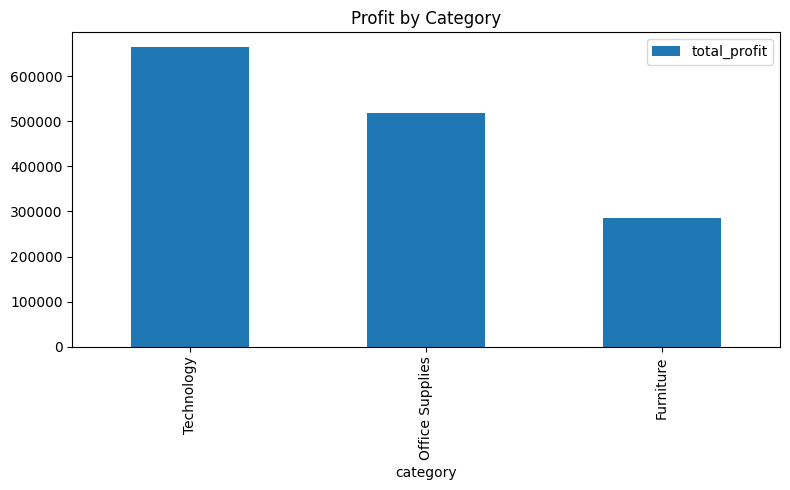

In [13]:
# 7. Profit por categoria
query = """
SELECT
    p.category,
    ROUND(SUM(od.profit),2) AS total_profit
FROM order_details od
JOIN products p
    ON od.product_id = p.product_id
GROUP BY p.category
ORDER BY total_profit DESC;
"""

profit_category = pd.read_sql(query, conn)
profit_category.plot(
    x="category",
    y="total_profit",
    kind="bar",
    figsize=(8,5)
)

plt.title("Profit by Category")
plt.tight_layout()
plt.savefig("../reports/Images/profit_category.png")
plt.show()

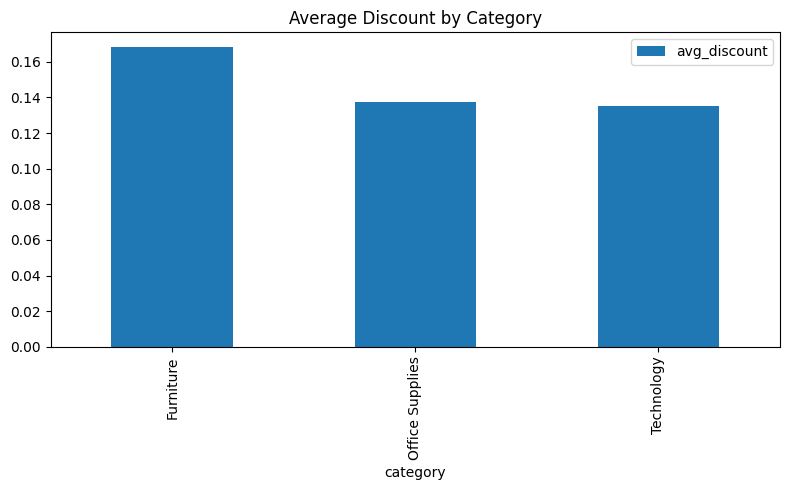

In [14]:
# 8. Descuento Promedio por categoria 
query = """
SELECT
    p.category,
    ROUND(AVG(od.discount),4) AS avg_discount
FROM order_details od
JOIN products p
    ON od.product_id = p.product_id
GROUP BY p.category
ORDER BY avg_discount DESC;
"""

discount_category = pd.read_sql(query, conn)
discount_category.plot(
    x="category",
    y="avg_discount",
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Discount by Category")
plt.tight_layout()
plt.savefig("../reports/Images/discount_category.png")
plt.show()

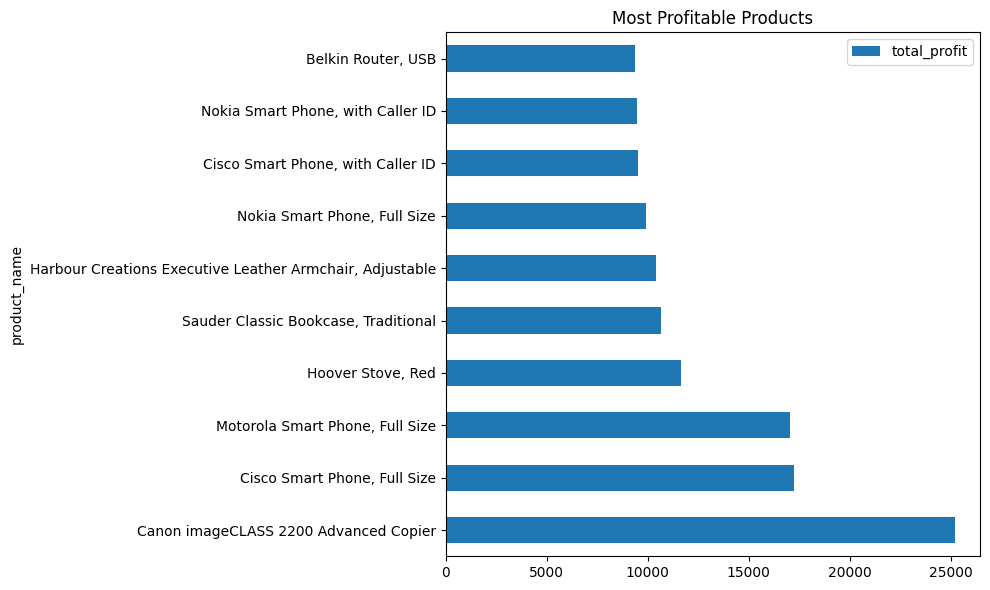

In [15]:
# 9. Productos mas rentables
query = """
SELECT
    p.product_name,
    ROUND(SUM(od.profit),2) AS total_profit
FROM order_details od
JOIN products p
    ON od.product_id = p.product_id
GROUP BY p.product_name
ORDER BY total_profit DESC
LIMIT 10;
"""

profitable_products = pd.read_sql(query, conn)
profitable_products.plot(
    x="product_name",
    y="total_profit",
    kind="barh",
    figsize=(10,6)
)

plt.title("Most Profitable Products")
plt.tight_layout()
plt.savefig("../reports/Images/profitable_products.png")
plt.show()

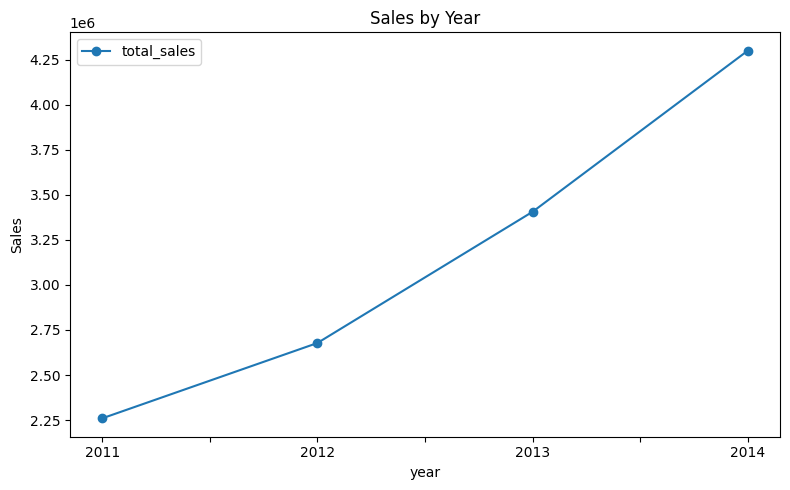

In [16]:
# 10. Ventas por año
query = """
SELECT
    strftime('%Y', o.order_date) AS year,
    ROUND(SUM(od.sales),2) AS total_sales
FROM order_details od
JOIN orders o
    ON od.order_id = o.order_id
GROUP BY year
ORDER BY year;
"""

sales_year = pd.read_sql(query, conn)
sales_year.plot(
    x="year",
    y="total_sales",
    kind="line",
    marker="o",
    figsize=(8,5)
)

plt.title("Sales by Year")
plt.ylabel("Sales")
plt.tight_layout()

plt.savefig("../reports/Images/sales_by_year.png")

plt.show()